In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

2026-03-17 18:48:49.991494: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773773330.184559      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773773330.239282      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773773330.722400      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773773330.722435      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773773330.722439      55 computation_placer.cc:177] computation placer alr

In [3]:
dataset_path = "/kaggle/input/datasets/tombackert/brain-tumor-mri-data/brain-tumor-mri-dataset"

In [4]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 5723 images belonging to 4 classes.
Found 1430 images belonging to 4 classes.


In [8]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

In [9]:
from tensorflow.keras.layers import Dropout

model = Sequential([

    Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128,activation='relu'),
    Dropout(0.5),

    Dense(4,activation='softmax')
])

In [11]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [12]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 20s 96ms/step - accuracy: 0.5671 - loss: 1.0045 - val_accuracy: 0.8168 - val_loss: 0.4477
Epoch 2/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 15s 81ms/step - accuracy: 0.8084 - loss: 0.4805 - val_accuracy: 0.8594 - val_loss: 0.3508
Epoch 3/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 14s 79ms/step - accuracy: 0.8784 - loss: 0.3150 - val_accuracy: 0.8951 - val_loss: 0.3054
Epoch 4/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 14s 80ms/step - accuracy: 0.9014 - loss: 0.2580 - val_accuracy: 0.9280 - val_loss: 0.2414
Epoch 5/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 14s 81ms/step - accuracy: 0.9331 - loss: 0.1772 - val_accuracy: 0.9350 - val_loss: 0.2088
Epoch 6/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 15s 82ms/step - accuracy: 0.9506 - loss: 0.1379 - val_accuracy: 0.9315 - val_loss: 0.2285
Epoch 7/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 15s 81ms/step - accuracy: 0.9577 - loss: 0.1214 - val_accuracy: 0.9364 - val_loss: 0.2270
Epoch 8/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 15s 82ms/step - accuracy: 0.9675 - loss: 0.0902 - 

In [13]:
loss,acc = model.evaluate(val_data)

print("Validation Accuracy:",acc)

45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - accuracy: 0.9333 - loss: 0.2316
Validation Accuracy: 0.9349650144577026


In [14]:
img_path = train_data.filepaths[0]

img = cv2.imread(img_path)
img = cv2.resize(img,(128,128))
img = img/255
img = np.expand_dims(img,axis=0)

pred = model.predict(img)

class_names = list(train_data.class_indices.keys())

print("Prediction:", class_names[np.argmax(pred)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 644ms/step
Prediction: glioma


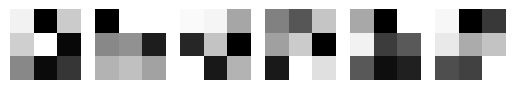

In [15]:
layer = model.layers[0]

filters, bias = layer.get_weights()

for i in range(6):
    f = filters[:,:,:,i]
    plt.subplot(1,6,i+1)
    plt.imshow(f[:,:,0], cmap='gray')
    plt.axis('off')

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step


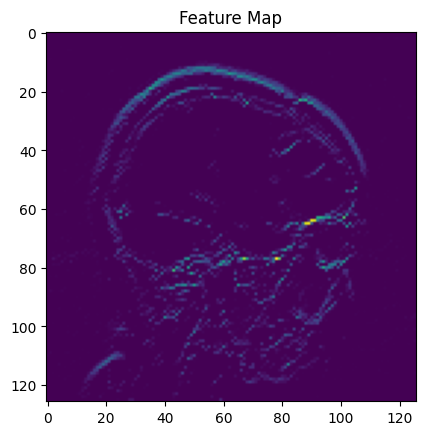

In [17]:
layer_outputs = [layer.output for layer in model.layers[:3]]

activation_model = Model(inputs=model.inputs, outputs=layer_outputs)

img = cv2.imread(img_path)
img = cv2.resize(img,(128,128))
img = img/255
img = np.expand_dims(img,axis=0)

activations = activation_model.predict(img)

feature_map = activations[0][0]

plt.imshow(feature_map[:,:,0], cmap='viridis')
plt.title("Feature Map")
plt.show()

Using layer: conv2d_5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step


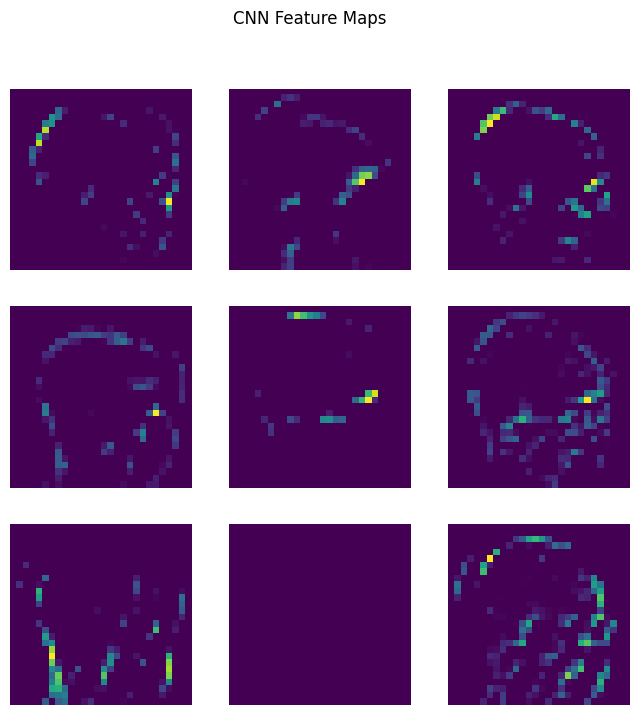

In [37]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

# pick an image
img_path = train_data.filepaths[0]

img = cv2.imread(img_path)
img = cv2.resize(img,(128,128))
img = img.astype("float32")/255.0
img = np.expand_dims(img,axis=0)

# choose a convolution layer
conv_layer = None
for layer in model.layers:
    if isinstance(layer, tf.keras.layers.Conv2D):
        conv_layer = layer.name

print("Using layer:", conv_layer)

# create feature map model
feature_model = tf.keras.models.Model(
    inputs=model.inputs,
    outputs=model.get_layer(conv_layer).output
)

# get feature maps
feature_maps = feature_model.predict(img)

# show first 9 feature maps
plt.figure(figsize=(8,8))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(feature_maps[0,:,:,i], cmap="viridis")
    plt.axis("off")

plt.suptitle("CNN Feature Maps")
plt.show()

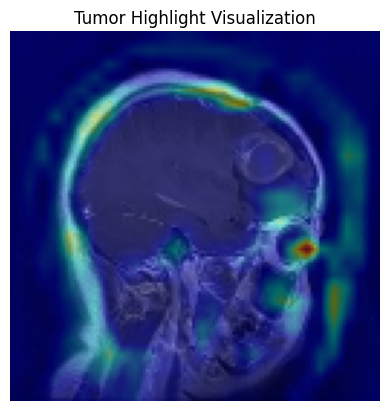

In [38]:
feature_map = feature_maps[0].mean(axis=-1)

feature_map = cv2.resize(feature_map,(128,128))

feature_map = (feature_map - feature_map.min()) / (feature_map.max() - feature_map.min())

heatmap = np.uint8(255 * feature_map)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

original = cv2.imread(img_path)
original = cv2.resize(original,(128,128))

overlay = cv2.addWeighted(original,0.6,heatmap,0.4,0)

plt.imshow(cv2.cvtColor(overlay,cv2.COLOR_BGR2RGB))
plt.title("Tumor Highlight Visualization")
plt.axis("off")
plt.show()